In [1]:
import pandas as pd 
from matplotlib import pyplot as plt
import seaborn as sbn
import numpy as np 

import torch

import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import r2_score
from sklearn.metrics import silhouette_score, silhouette_samples
import umap
from scipy.stats import spearmanr
from statsmodels.stats.multitest import multipletests

from amlvae.models.VAE import VAE 
from amlvae.train.Trainer import Trainer

from amlvae.data.ExprProcessor import ExprProcessor
from amlvae.data.ClinProcessor import ClinProcessor

from sklearn.model_selection import KFold

from sklearn.metrics import pairwise_distances
from sklearn.model_selection import train_test_split

import umap 
from sklearn.decomposition import PCA

# auto reimport 
%load_ext autoreload
%autoreload 2

# VAE + Drug response -> generalization to MDS 

Use beatAML "priorMDS=y" as the drug response test set. 

In [2]:
mds_expr = pd.read_csv('../data/20241219_WTS_Data_Proj805.csv', sep='\t').drop(columns=['counts']).rename(columns={'gene_id':'gene_name', 'array_id':'id'}).assign(id_type='array_id')
mds_expr = mds_expr.dropna() 
mds_expr.head() 

,id,gene_name,FPKM,id_type
0,MLL_00003,DDX11L1,0.061998,array_id
1,MLL_00003,WASH7P,2.672530,array_id
3,MLL_00003,MIR6859-2,0.000000,array_id
4,MLL_00003,MIR6859-4,0.000000,array_id
5,MLL_00003,MIR6859-1,0.000000,array_id


In [3]:
aml_expr = pd.read_csv('../data/aml_full_manuscript.csv')[['id', 'gene_name', 'fpkm_unstranded']].rename(columns={'fpkm_unstranded': 'FPKM'}).assign(id_type='gdc_id')
aml_expr = aml_expr.dropna() 
aml_expr = aml_expr.groupby(['id', 'gene_name', 'id_type']).max().reset_index() # use max to resolve duplicates (usually a zero and a non-zero)
aml_expr.head()

,id,gene_name,id_type,FPKM
0,001454b2-aff9-4659-85a6-73fb8092589a,5S_rRNA,gdc_id,1.2517
1,001454b2-aff9-4659-85a6-73fb8092589a,5_8S_rRNA,gdc_id,0.2182
2,001454b2-aff9-4659-85a6-73fb8092589a,7SK,gdc_id,0.0000
3,001454b2-aff9-4659-85a6-73fb8092589a,A1BG,gdc_id,0.1161
4,001454b2-aff9-4659-85a6-73fb8092589a,A1BG-AS1,gdc_id,0.5899


In [4]:
aml_stats = aml_expr.groupby('gene_name')['FPKM'].agg(['mean', 'std']).reset_index()
mds_stats = mds_expr.groupby('gene_name')['FPKM'].agg(['mean', 'std']).reset_index() 
stats = aml_stats.merge(mds_stats, on='gene_name', suffixes=('_aml', '_mds'))
stats = stats.assign(mean_diff=lambda x: x['mean_aml'] - x['mean_mds'],
             std_diff=lambda x: x['std_aml'] - x['std_mds'])
stats = stats.assign(tstat = lambda x: x['mean_diff'] / np.sqrt((x['std_aml']**2 + x['std_mds']**2) / 2))

candidate_genes = stats[lambda x: x.tstat.abs() < 0.25].gene_name.tolist() 

len(candidate_genes)

6730

In [5]:
# find the overlapping gene_names between the two datasets. 
overlap_genes = set(mds_expr['gene_name']).intersection(set(aml_expr['gene_name']))
print(f'Number of overlapping genes: {len(overlap_genes)}')
non_overlap_genes_mds = set(mds_expr['gene_name']).difference(overlap_genes)
non_overlap_genes_aml = set(aml_expr['gene_name']).difference(overlap_genes)
print(f'Number of non-overlapping genes in AML: {len(non_overlap_genes_aml)}')
print(f'Number of non-overlapping genes in MDS: {len(non_overlap_genes_mds)}')

Number of overlapping genes: 23220
Number of non-overlapping genes in AML: 36207
Number of non-overlapping genes in MDS: 3008


In [6]:
mds_expr = mds_expr[lambda x: x['gene_name'].isin(overlap_genes) & x['gene_name'].isin(candidate_genes)]
aml_expr = aml_expr[lambda x: x['gene_name'].isin(overlap_genes) & x['gene_name'].isin(candidate_genes)]

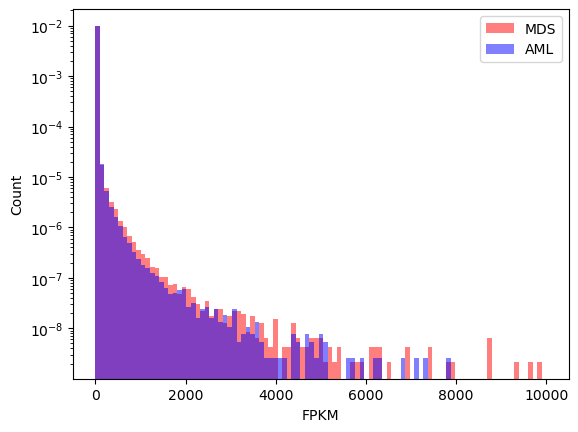

In [7]:
plt.figure() 
plt.hist(mds_expr['FPKM'], bins=np.linspace(0, 10000, 100), alpha=0.5, label='MDS', color='r', density=True)
plt.hist(aml_expr['FPKM'], bins=np.linspace(0, 10000, 100), alpha=0.5, label='AML', color='b', density=True)
plt.xlabel('FPKM')
plt.ylabel('Count')
plt.legend()
plt.yscale('log')
plt.show() 

In [8]:
topk = 2500
stats = stats[lambda x: x.gene_name.isin(candidate_genes) & x.gene_name.isin(overlap_genes)]
mds_topk_genes = stats.sort_values('std_mds', ascending=False).head(topk).gene_name.tolist()
aml_topk_genes = stats.sort_values('std_aml', ascending=False).head(topk).gene_name.tolist() 

topk_genes = np.sort(list(set(mds_topk_genes).intersection(set(aml_topk_genes)) )).tolist()
len(topk_genes)

2042

In [10]:
mds_expr = mds_expr[lambda x: x['gene_name'].isin(topk_genes)]
aml_expr = aml_expr[lambda x: x['gene_name'].isin(topk_genes)] 

In [11]:
# convert to log(FPKM + 1)
mds_expr = mds_expr.assign(log_FPKM=lambda x: np.log2(x['FPKM'] + 1))
aml_expr = aml_expr.assign(log_FPKM=lambda x: np.log2(x['FPKM'] + 1)) 

In [12]:
# zscore 
# NOTE: we zscore both datasets with the MDS stats 
log_stats_mds = mds_expr.groupby('gene_name')['log_FPKM'].agg(['mean', 'std']).reset_index()  

In [13]:
mds_expr = mds_expr.merge(log_stats_mds, on='gene_name') 
aml_expr = aml_expr.merge(log_stats_mds, on='gene_name') 

In [14]:
mds_expr = mds_expr.assign(zscore_FPKM=lambda x: (x['log_FPKM'] - x['mean']) / x['std'])
aml_expr = aml_expr.assign(zscore_FPKM=lambda x: (x['log_FPKM'] - x['mean']) / x['std'])

In [15]:
mds_expr = mds_expr.rename(columns={'gene_id':'gene_name', 'array_id':'id'})

In [16]:
# convert to wide format
mds_expr_wide = mds_expr.pivot(index='id', columns='gene_name', values='zscore_FPKM')
aml_expr_wide = aml_expr.pivot(index='id', columns='gene_name', values='zscore_FPKM')

In [17]:
aml_expr_wide = aml_expr_wide.fillna(0)
mds_expr_wide = mds_expr_wide.fillna(0) 

X_aml = aml_expr_wide[topk_genes].values
X_mds = mds_expr_wide[topk_genes].values 

aml_ids = aml_expr_wide.index.tolist()
mds_ids = mds_expr_wide.index.tolist() 

In [18]:
X = np.concatenate([X_aml, X_mds], axis=0)
ids = aml_ids + mds_ids 

In [19]:
aml_clin = pd.read_csv('../data/beataml_clinical_for_inputs.csv')
priorMDS_ids = aml_clin[lambda x: x.priorMDS == 'y'].gdc_id.unique()

In [20]:
test_mask = np.isin(ids, priorMDS_ids)
x_test = X[test_mask]

candidate_ids = [i for i in ids if i not in priorMDS_ids] 
train_ids, val_ids = train_test_split(candidate_ids, test_size=0.15, random_state=42)

train_mask = np.isin(ids, train_ids)
x_train = X[train_mask]

val_mask = np.isin(ids, val_ids)
x_val = X[val_mask] 

print(f'Train set size: {x_train.shape}')
print(f'Test set size: {x_test.shape}')
print(f'Val set size: {x_val.shape}')

Train set size: (1014, 2042)
Test set size: (49, 2042)
Val set size: (180, 2042)


In [21]:
x_train = torch.tensor(x_train, dtype=torch.float32)
x_val = torch.tensor(x_val, dtype=torch.float32)
x_test = torch.tensor(x_test, dtype=torch.float32)

In [22]:
train_ids[0:5]

['MLL_11600',
 'a510feab-48be-48e2-9d7f-74500cb7b0b6',
 '7b45ebc6-9845-477a-a2d4-988c1ccf96ec',
 'fb0acfd8-ca70-44cc-9bfd-2445094729af',
 '6b3132a6-24ae-4bbf-a7eb-31701e5988e3']

In [23]:
x_train

tensor([[-1.9582e-01,  1.3957e-01, -1.5127e+00,  ...,  1.4309e+00,
          9.1738e-01,  2.6550e+00],
        [ 8.8840e-01, -5.1184e-01,  3.9750e+00,  ...,  1.8166e+00,
         -1.4600e+00,  5.1193e-01],
        [ 4.7768e-02,  9.9093e-01, -1.3451e+00,  ...,  1.6139e+00,
          1.3311e+00,  2.4071e+00],
        ...,
        [-6.4781e-01, -4.4441e-01, -2.4716e-01,  ...,  6.7069e-01,
         -7.7978e-01, -9.1861e-01],
        [-1.1786e-01,  2.2828e-01,  2.1231e+00,  ...,  5.2218e-03,
          1.8969e+00,  1.9332e-01],
        [ 3.9961e-01, -3.3345e+00,  5.8764e-01,  ...,  1.0537e+00,
         -1.1572e+00, -5.3129e-04]])

In [108]:
# set random seed
torch.manual_seed(42)
np.random.seed(42)

In [109]:
model_kwargs = {
            'input_dim'   : x_train.size(1),
            'hidden_dim'  : 1024,
            'n_layers'    : 2,
            'latent_dim'  : 32,
            'norm'        : 'layer',
            'variational' : True,
            'dropout'     : 0.,
            'nonlin'      : 'elu'
        }

lr = 5e-5 
l2 = 0
epochs = 250
beta = 10.0
batch_size = 128

device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = VAE(**model_kwargs).to(device)
optim = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=l2)

In [110]:
x_train = x_train.to(device)
x_val = x_val.to(device)
x_test = x_test.to(device)

In [ ]:
best_elbo = float('inf')
patience_count = 0 
best_model = None 

for epoch in range(epochs): 

    model.train()
    losses = []
    for ixs in torch.split(torch.randperm(len(x_train)), batch_size):

        optim.zero_grad()
        x = x_train[ixs].to(device)
        
        out = model(x)
        loss, mse, kld, lm = model.loss(x, beta=beta, **out)

        loss.backward()
        optim.step()
        losses.append(loss.item())
    losses = np.mean(losses) 

    model.eval() 
    with torch.no_grad():   
        xhat = model(x_val)['xhat']
        val_r2  = r2_score(x_val.cpu().numpy(), xhat.cpu().numpy(), multioutput='uniform_average')
        val_mse = np.mean((x_val.cpu().numpy() - xhat.cpu().numpy())**2)

    print(f'Epoch {epoch+1}/{epochs}, Loss: {losses:.4f}, MSE: {mse:.4f}, KLD: {kld:.4f}, LM: {lm:.4f}, val R2: {val_r2:.3f}, val mse: {val_mse:.2f}', end='\r')



In [112]:
model.eval() 
with torch.no_grad():   
    xhat = model(x_test)['xhat']
    test_r2  = r2_score(x_test.cpu().numpy(), xhat.cpu().numpy(), multioutput='uniform_average')
    test_mse = np.mean((x_test.cpu().numpy() - xhat.cpu().numpy())**2)

print(f'\nTest R2: {test_r2:.3f}')
print(f'Test MSE: {test_mse:.3f}')


Test R2: 0.270
Test MSE: 0.986


In [113]:
with torch.no_grad(): 
    z, _ = model.encode(torch.tensor(X, dtype=torch.float32).to(device))

In [114]:
zdf = pd.DataFrame(z.cpu().numpy(), columns=[f'z{i}' for i in range(z.size(1))])
zdf = zdf.assign(id=ids)
zdf = zdf.assign(priorMDS_ids = np.isin(ids, priorMDS_ids))
zdf = zdf.assign(id_type = ['aml']*len(aml_ids) + ['mds']*len(mds_ids))
zdf.head() 

,z0,z1,z2,z3,z4,z5,z6,z7,z8,z9,...,z25,z26,z27,z28,z29,z30,z31,id,priorMDS_ids,id_type
0,-1.348740,-1.118616,-0.736633,1.152074,0.755404,0.323266,1.442539,-0.599680,0.514231,1.423071,...,-1.455286,-0.884422,-1.429239,-0.124257,0.271681,1.097555,-0.302630,001454b2-aff9-4659-85a6-73fb8092589a,False,aml
1,-0.155753,-0.860864,1.786781,-0.504257,0.099433,1.466959,-0.037944,-1.631009,-0.468950,0.943315,...,-0.395437,0.060335,0.711511,1.017760,1.479952,1.553392,-0.911647,002cacd9-c03b-4526-a380-0701f41c4a9e,False,aml
2,-0.182059,0.282600,0.238091,-0.175212,1.145837,-0.044590,-0.432668,-0.360441,1.254283,0.033300,...,0.262252,-1.111405,1.017475,1.304059,-0.024610,-1.413541,-1.497597,006e5777-2603-4db7-a1d6-8c8085c5e3e5,False,aml
3,1.398580,-0.072657,0.513388,-0.711000,-0.161938,1.333953,-1.069844,0.079196,0.693906,0.317127,...,-0.677520,0.613347,-0.308798,0.100888,-1.115547,-0.540920,0.759139,00870f33-cab3-4c23-bd0d-8903a5a9789e,False,aml
4,0.581755,-0.533485,-0.927716,1.083344,0.479520,-0.873023,0.479774,-0.028544,-0.644865,1.558356,...,2.186776,-0.400236,0.611995,0.515475,1.552123,-0.913061,-0.558466,00b535f6-064a-4dcf-ab14-387a54eedeee,False,aml


In [115]:
zdf.head() 

,z0,z1,z2,z3,z4,z5,z6,z7,z8,z9,...,z25,z26,z27,z28,z29,z30,z31,id,priorMDS_ids,id_type
0,-1.348740,-1.118616,-0.736633,1.152074,0.755404,0.323266,1.442539,-0.599680,0.514231,1.423071,...,-1.455286,-0.884422,-1.429239,-0.124257,0.271681,1.097555,-0.302630,001454b2-aff9-4659-85a6-73fb8092589a,False,aml
1,-0.155753,-0.860864,1.786781,-0.504257,0.099433,1.466959,-0.037944,-1.631009,-0.468950,0.943315,...,-0.395437,0.060335,0.711511,1.017760,1.479952,1.553392,-0.911647,002cacd9-c03b-4526-a380-0701f41c4a9e,False,aml
2,-0.182059,0.282600,0.238091,-0.175212,1.145837,-0.044590,-0.432668,-0.360441,1.254283,0.033300,...,0.262252,-1.111405,1.017475,1.304059,-0.024610,-1.413541,-1.497597,006e5777-2603-4db7-a1d6-8c8085c5e3e5,False,aml
3,1.398580,-0.072657,0.513388,-0.711000,-0.161938,1.333953,-1.069844,0.079196,0.693906,0.317127,...,-0.677520,0.613347,-0.308798,0.100888,-1.115547,-0.540920,0.759139,00870f33-cab3-4c23-bd0d-8903a5a9789e,False,aml
4,0.581755,-0.533485,-0.927716,1.083344,0.479520,-0.873023,0.479774,-0.028544,-0.644865,1.558356,...,2.186776,-0.400236,0.611995,0.515475,1.552123,-0.913061,-0.558466,00b535f6-064a-4dcf-ab14-387a54eedeee,False,aml


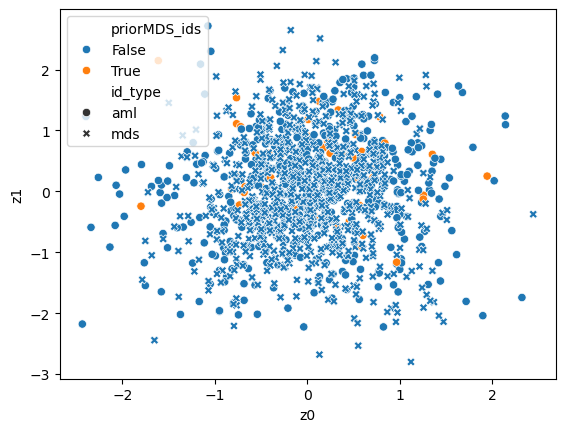

In [98]:

plt.figure()
sbn.scatterplot(data=zdf, x='z0', y='z1', style='id_type', hue='priorMDS_ids', alpha=1.)  
plt.show()   

/home/teddy/miniconda3/envs/amlvae/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/teddy/miniconda3/envs/amlvae/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


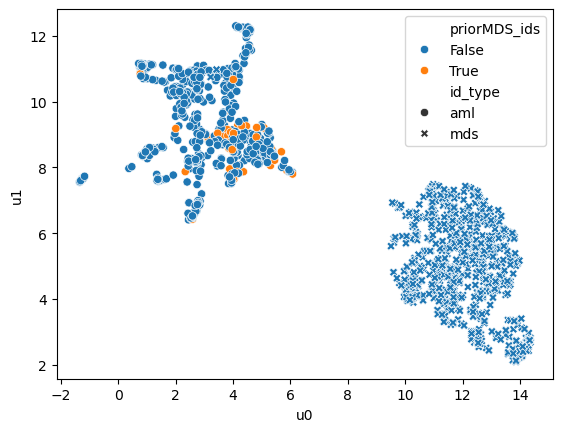

In [99]:
reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1) 

u = reducer.fit_transform(z.cpu().numpy()) 

udf = pd.DataFrame(u, columns=['u0', 'u1'])
udf = udf.assign(id=ids)
udf = udf.assign(priorMDS_ids = np.isin(ids, priorMDS_ids))
udf = udf.assign(id_type = ['aml']*len(aml_ids) + ['mds']*len(mds_ids))

plt.figure()
sbn.scatterplot(data=udf, x='u0', y='u1', style='id_type', hue='priorMDS_ids', alpha=1.)
plt.show()

In [104]:
drug = pd.read_csv('../data/beataml_probit_curve_fits_v4_distr.txt', sep='\t').merge(aml_clin[['gdc_id', 'labId']], left_on='lab_id', right_on='labId', how='inner') 
drug = drug[['gdc_id', 'inhibitor', 'auc']]
drug = drug[lambda x: x.inhibitor == 'Venetoclax']
drug.head() 

,gdc_id,inhibitor,auc
11150,10e40b12-066c-4b63-82b3-901571c9bf34,Venetoclax,54.093800
11396,4975f3a3-29b9-4435-b7f1-54631944917a,Venetoclax,186.198826
11554,741dbfbb-5d9b-4aac-85d4-8b22a2d8e6b5,Venetoclax,131.223767
11718,ff244ddf-f003-452c-bb2e-3516efb14b1a,Venetoclax,286.304063
11837,8871255a-18d2-47f7-9485-8141bf202c55,Venetoclax,213.532983


In [105]:
zdf = zdf.merge(drug, left_on='id', right_on='gdc_id', how='left')

In [107]:
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier

In [94]:
zdf = zdf[lambda x: x['auc'].notna()]

z_test = zdf[lambda x: x.gdc_id.isin(priorMDS_ids)][zdf.columns[:model.latent_dim]].values 
y_test = zdf[lambda x: x.gdc_id.isin(priorMDS_ids)]['auc'].values 

z_train = zdf[~zdf.gdc_id.isin(priorMDS_ids)][zdf.columns[:model.latent_dim]].values
y_train = zdf[~zdf.gdc_id.isin(priorMDS_ids)]['auc'].values 

yt = np.quantile(y_train, 0.5) 

y_train = y_train < yt
y_test = y_test < yt 

mod = RandomForestClassifier(n_estimators=500)

scores = cross_val_score(mod, z_train, y_train, cv=5, scoring='roc_auc')
print(f'Cross-validated ROC AUC: {np.mean(scores):.3f} +/- {np.std(scores):.3f}')

mod.fit(z_train, y_train)
y_pred = mod.predict_proba(z_test)[:, 1]

from sklearn.metrics import roc_auc_score, accuracy_score
roc_auc = roc_auc_score(y_test, y_pred)
acc = accuracy_score(y_test, y_pred > 0.5)
print(f'Test ROC AUC: {roc_auc:.3f}')   
print(f'Test accuracy: {acc:.3f}')

Cross-validated ROC AUC: 0.859 +/- 0.045
Test ROC AUC: 0.797
Test accuracy: 0.793


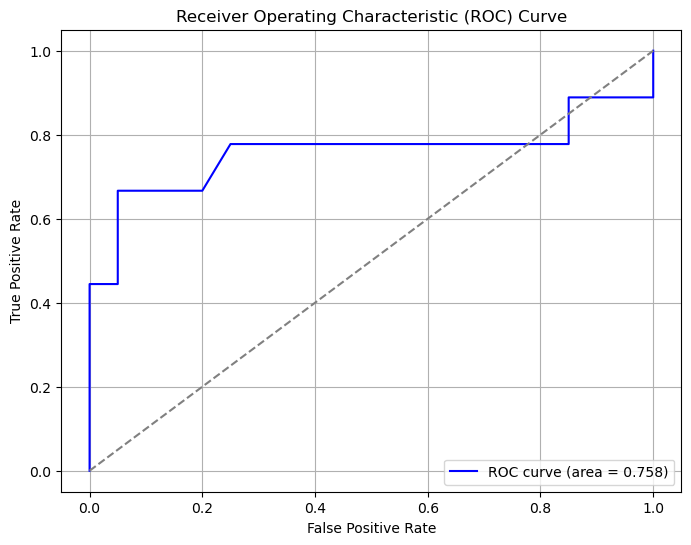

In [37]:
# auroc curve 
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label='ROC curve (area = {:.3f})'.format(roc_auc), color='blue')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid()
plt.show()

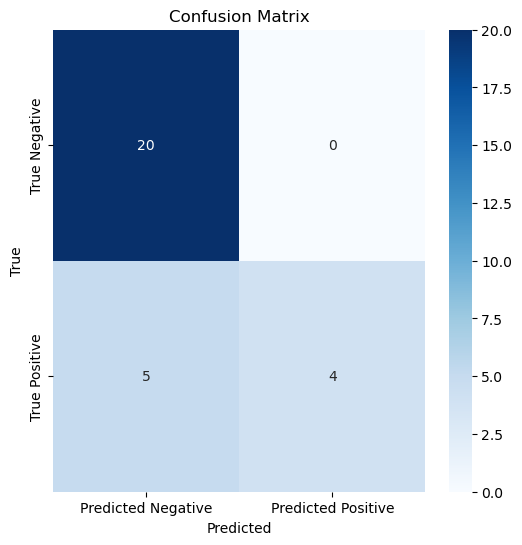

In [38]:
# confusion 
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred > 0.5)
import seaborn as sns
plt.figure(figsize=(6, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted Negative', 'Predicted Positive'], yticklabels=['True Negative', 'True Positive'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

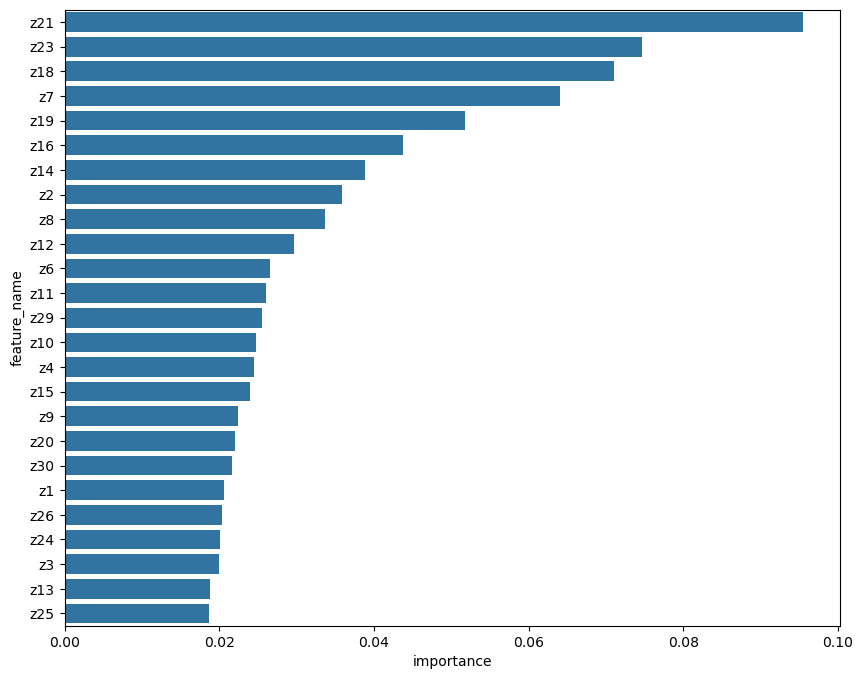

In [39]:
imp_df = pd.DataFrame({'importance':mod.feature_importances_, 'feature_name' : [f'z{i}' for i in range(model.latent_dim)]}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 8))
sbn.barplot(data=imp_df.head(25), y='feature_name', x='importance') 
plt.show() 

In [40]:
zdf[imp_df.feature_name.values[0:3]].corr()

,z21,z23,z18
z21,1.000000,-0.440412,-0.054269
z23,-0.440412,1.000000,0.565078
z18,-0.054269,0.565078,1.000000


In [41]:
# what does z31 look like in MDS patients? (do distributions mds/aml overlap or separate?)
# run this analysis with azacitadine
# " ven + aza (relatively few patients) and other ven combinations.
# joint expr + mut vae embeddings (select mut features baseed on aml/mds frequency similarity.)
# celltype scoring (beataml) compared to z31 
# what genes are predictive of z31? what mut/sv might drive z31 signature --> corr. with z31 mut/sv  

Spearman correlation between z11 and z27: 0.469, p-value: 2.469e-18


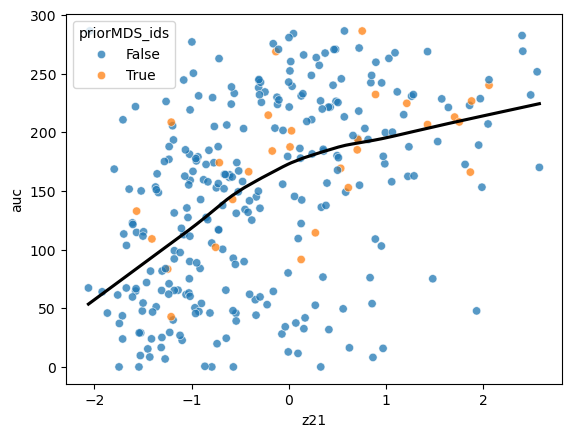

Spearman correlation between z11 and z27: -0.505, p-value: 1.917e-21


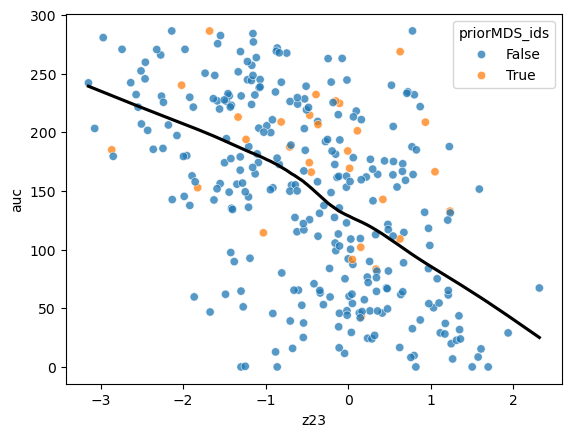

Spearman correlation between z11 and z27: -0.445, p-value: 1.914e-16


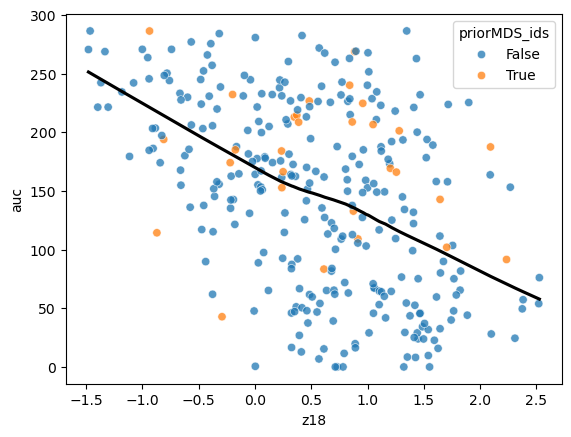

In [42]:
for f1 in imp_df.feature_name.values[:3]:

    corr = spearmanr(zdf[f1], zdf.auc)
    print(f'Spearman correlation between z11 and z27: {corr.statistic:.3f}, p-value: {corr.pvalue:.3e}')

    plt.figure() 
    sbn.scatterplot(data=zdf, x=f1, y='auc', hue='priorMDS_ids', alpha=0.75)
    sbn.regplot(data=zdf, x=f1, y='auc', ci=True, lowess=True, scatter=False, color='black')
    plt.show() 

In [43]:
aml_clin.head() 

,gdc_id,patientId,labId,dbgap_subject_id,dbgap_rnaseq_sample,dbgap_dnaseq_sample,rna_set,dna_set,cohort,manuscript_rnaseq,...,dxAtSpecimenAcquisition,isTransformed,priorMDS,FLT3-ITD,allelic_ratio,NPM1,RUNX1,ASXL1,TP53,ELN2017
0,d6cbfa6d-0fa9-47da-aefa-548f22574cb5,50,12-00426,2269,BA2922R,NaN,train,none,Waves1+2,yes,...,ACUTE MYELOID LEUKAEMIA (AML) AND RELATED PREC...,FALSE,n,positive,NaN,NaN,NaN,NaN,NaN,NonInitial
1,df27ad08-d16e-4a8f-8c31-f137073126d6,550,12-00023,2418,BA2409R,NaN,train,none,Waves1+2,yes,...,ACUTE MYELOID LEUKAEMIA (AML) AND RELATED PREC...,FALSE,n,negative,0.000000,negative,NaN,NaN,NaN,Intermediate
2,1de5aec8-893f-4e67-b70c-39386faa5348,555,12-00372,2374,BA2480R,NaN,train,none,Waves1+2,yes,...,ACUTE MYELOID LEUKAEMIA (AML) AND RELATED PREC...,FALSE,n,positive,2.448276,positive,NaN,NaN,NaN,NonInitial
3,f2866e90-b893-46fc-96a3-57939324d3e0,559,12-00066,2099,BA2496R,NaN,train,none,Waves1+2,yes,...,ACUTE MYELOID LEUKAEMIA (AML) AND RELATED PREC...,TRUE,n,positive,0.111111,negative,NaN,NaN,NaN,MissingMutations
4,1ba65878-426c-439a-b0dc-8537c09ab422,635,12-00051,2391,BA3037R,NaN,train,none,Waves1+2,yes,...,ACUTE MYELOID LEUKAEMIA (AML) AND RELATED PREC...,FALSE,n,positive,NaN,positive,NaN,NaN,NaN,FavorableOrIntermediate


In [44]:
celltype = pd.read_excel('../data/beataml_wv_1to4_vg_cts.xlsx').merge(aml_clin[['gdc_id', 'labId']], on='labId', how='inner')
celltype = celltype[['gdc_id', 'GMP-like', 'HSC-like', 'Monocyte-like', 'Progenitor-like', 'Promono-like', 'cDC-like']]
zdf = zdf.merge(celltype, on='gdc_id', how='left')

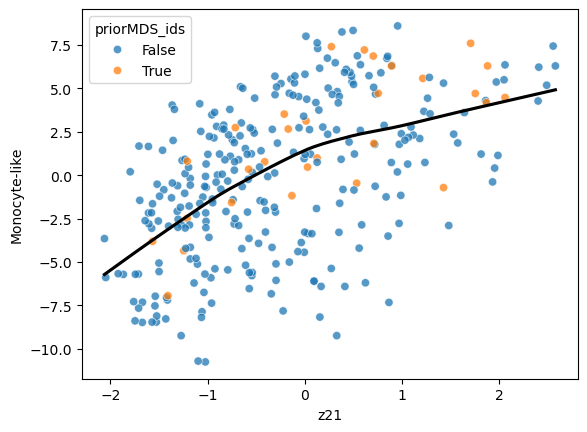

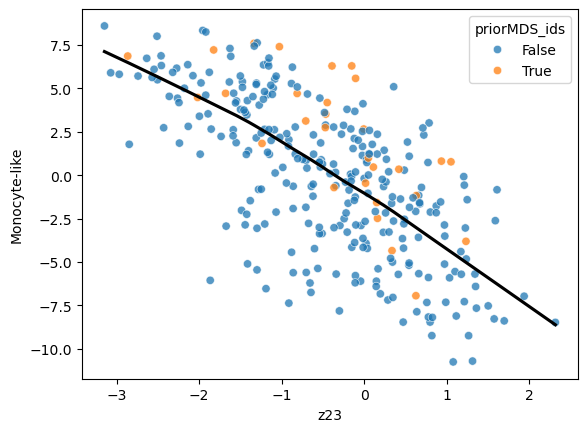

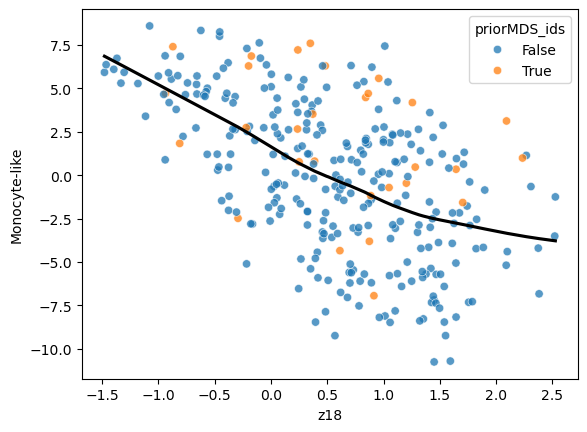

In [45]:
for f1 in imp_df.feature_name.values[:3]:

    plt.figure() 
    sbn.scatterplot(data=zdf, x=f1, y='Monocyte-like', hue='priorMDS_ids', alpha=0.75)
    sbn.regplot(data=zdf, x=f1, y='Monocyte-like', ci=True, lowess=True, scatter=False, color='black')
    plt.show() 

In [46]:
zdf = pd.DataFrame(z.cpu().numpy(), columns=[f'z{i}' for i in range(z.size(1))])
zdf = zdf.assign(id=ids)
zdf = zdf.assign(priorMDS_ids = np.isin(ids, priorMDS_ids))
zdf = zdf.assign(id_type = ['aml']*len(aml_ids) + ['mds']*len(mds_ids))

zdf = zdf.merge(aml_clin[['gdc_id', 'overallSurvival']], left_on='id', right_on='gdc_id', how='left')

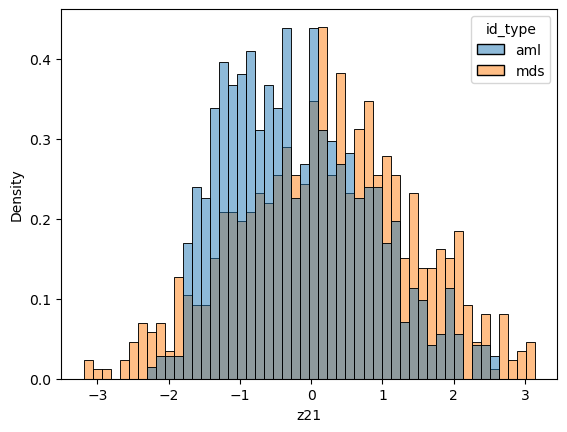

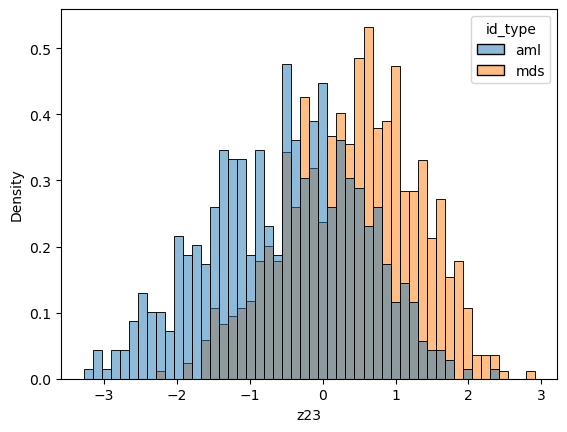

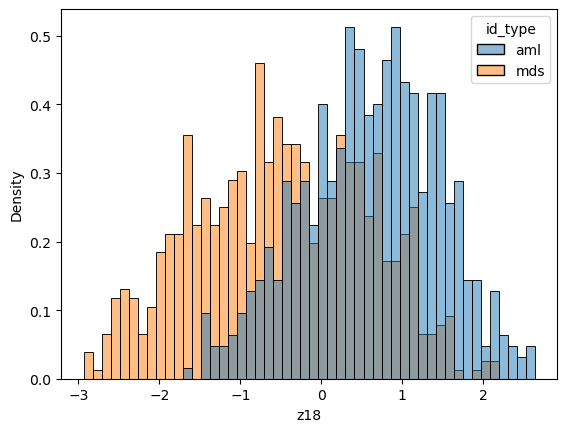

In [47]:
for f1 in imp_df.feature_name.values[:3]:

    plt.figure() 
    sbn.histplot(data=zdf, x=f1, hue='id_type', stat='density', common_norm=False, bins=50)
    plt.show() 

In [48]:
aml_train_mut = pd.read_csv('../data/aml_train.csv').merge(aml_clin[['gdc_id', 'dbgap_dnaseq_sample']].drop_duplicates().dropna() , on='dbgap_dnaseq_sample', how='inner')
zdf2 = zdf.merge(aml_train_mut, on='gdc_id', how='left')
zdf2 = zdf2.dropna() 
zdf2.head() 

,z0,z1,z2,z3,z4,z5,z6,z7,z8,z9,...,SLC17A3,MXRA5,CBFB,MYH11,BCR,ABL1,MLLT3,PML,RARA,RUNX1T1
1,0.515790,0.412993,0.017197,2.442547,1.360569,0.351327,1.145571,-1.471444,0.261820,0.313241,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.736698,-0.165228,1.025079,-0.643331,-0.323848,-0.899103,-0.486344,-1.201925,0.168681,1.153873,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.495513,1.397167,-0.986481,0.416896,0.208037,-0.331653,-0.722797,1.261837,0.217911,0.144275,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.460235,-0.581536,-0.730894,0.449735,-1.756618,-0.327061,2.423966,1.105051,-0.010630,0.172876,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,0.299552,-0.964635,0.303539,-0.837163,1.890761,1.403215,-1.171342,0.575725,-0.013949,0.596981,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [49]:
zdf2.shape

(481, 169)

In [50]:
from sklearn.ensemble import RandomForestRegressor

In [51]:
latent_idx = 2

x = zdf2[aml_train_mut.columns[1:-1]].values
y = zdf2[imp_df.feature_name.values[latent_idx]].values

rf = RandomForestRegressor(n_estimators=1000, max_depth=3)

# cv scorer 
score = cross_val_score(rf, x, y, cv=5, scoring='r2')
print(f'Cross-validated R2: {np.mean(score):.3f} +/- {np.std(score):.3f}')

rf.fit(x, y)

# score 

Cross-validated R2: 0.048 +/- 0.035


RandomForestRegressor(max_depth=3, n_estimators=1000)

In [52]:
aml_test_mut = pd.read_csv('../data/aml_test.csv').merge(aml_clin[['gdc_id', 'dbgap_dnaseq_sample']].drop_duplicates().dropna() , on='dbgap_dnaseq_sample', how='inner')
zdf3 = zdf.merge(aml_test_mut, on='gdc_id', how='left')
zdf3 = zdf3.dropna() 

x = zdf3[aml_test_mut.columns[1:-1]].values
y = zdf3[imp_df.feature_name.values[latent_idx]].values
print(f'Test set size: {x.shape}')

yhat = rf.predict(x)

r2_test = r2_score(y, yhat)
print(f'Test R2: {r2_test:.3f}')

Test set size: (49, 131)
Test R2: -0.007


In [53]:
imp_df2 = pd.DataFrame({'feature_name': aml_train_mut.columns[1:-1], 'importance': rf.feature_importances_}).sort_values('importance', ascending=False).head(25)
imp_df2.head() 

,feature_name,importance
34,NRAS,0.182468
1,IDH1,0.109215
2,NPM1,0.099270
4,FLT3,0.076911
7,IDH2,0.074840


In [54]:
mut_res = {'mut':[], 'latent_feat':[], 'statistic':[], 'pval':[]}
for latent_feat in imp_df.feature_name.values[:3]:
    for mut_feat in aml_train_mut.columns[1:-1]: 
        x = zdf2[lambda x:  ~x[mut_feat].isna()][latent_feat].values
        y = zdf2[lambda x:  ~x[mut_feat].isna()][mut_feat].values
        corr = spearmanr(x, y)
        mut_res['mut'].append(mut_feat)
        mut_res['latent_feat'].append(latent_feat)
        mut_res['statistic'].append(corr.statistic)
        mut_res['pval'].append(corr.pvalue)

mut_res = pd.DataFrame(mut_res).dropna() 
mut_res = mut_res.assign(qval=lambda x: multipletests(x['pval'], method='fdr_bh', )[1])
mut_res = mut_res.sort_values('qval').reset_index(drop=True) 
mut_res.head() 

/tmp/ipykernel_9902/2002659805.py:6: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr = spearmanr(x, y)


,mut,latent_feat,statistic,pval,qval
0,NRAS,z18,-0.210422,0.000003,0.000296
1,GATA2,z23,0.213774,0.000002,0.000296
2,CBFB,z23,-0.210985,0.000003,0.000296
3,MYH11,z23,-0.210985,0.000003,0.000296
4,CEBPA,z23,0.204408,0.000006,0.000454


In [55]:
mut_res[lambda x: x.latent_feat == imp_df.feature_name.values[0]].sort_values('qval').head(10)

,mut,latent_feat,statistic,pval,qval
17,MYH11,z21,0.125780,0.005738,0.105009
19,CBFB,z21,0.125780,0.005738,0.105009
22,GATA2,z21,-0.112099,0.013899,0.221168
23,NRAS,z21,0.110671,0.015168,0.231312
24,FLT3,z21,-0.109986,0.015812,0.231492
26,SLC12A1,z21,0.103078,0.023770,0.314886
27,TSKS,z21,-0.102846,0.024090,0.314886
31,STAG2,z21,0.099263,0.029502,0.337431
32,SMC3,z21,0.095301,0.036670,0.406700
37,FRYL,z21,-0.088885,0.051393,0.495001


In [56]:
mut_res[lambda x: x.latent_feat == imp_df.feature_name.values[1]].sort_values('qval').head(10).style.hide()

mut,latent_feat,statistic,pval,qval
GATA2,z23,0.213774,0.000002,0.000296
CBFB,z23,-0.210985,0.000003,0.000296
MYH11,z23,-0.210985,0.000003,0.000296
CEBPA,z23,0.204408,0.000006,0.000454
KMT2A,z23,-0.200318,0.000010,0.000583
IDH1,z23,0.197219,0.000013,0.000690
MLLT3,z23,-0.171368,0.000159,0.005819
NRAS,z23,-0.152624,0.000784,0.022081
KRAS,z23,-0.143708,0.001578,0.041250
WT1,z23,0.119065,0.008954,0.148958


In [57]:
mut_res[lambda x: x.latent_feat == imp_df.feature_name.values[2]].sort_values('qval').head(10)

,mut,latent_feat,statistic,pval,qval
0,NRAS,z18,-0.210422,0.000003,0.000296
7,FLT3,z18,0.183076,0.000054,0.002457
8,NPM1,z18,0.181101,0.000065,0.002635
10,IDH2,z18,0.168488,0.000205,0.006837
11,IDH1,z18,0.162304,0.000351,0.010720
14,CBFB,z18,-0.133218,0.003421,0.073646
15,KRAS,z18,-0.134866,0.003040,0.073646
16,MYH11,z18,-0.133218,0.003421,0.073646
18,KMT2A,z18,-0.125951,0.005672,0.105009
20,PARP14,z18,0.121147,0.007818,0.136251


In [58]:
mut_res = {'mut':[], 'latent_feat':[], 'statistic':[], 'pval':[]}
for latent_feat in imp_df.feature_name.values[:3]:
    for mut_feat in aml_test_mut.columns[1:-1]: 
        x = zdf3[lambda x:  ~x[mut_feat].isna()][latent_feat].values
        y = zdf3[lambda x:  ~x[mut_feat].isna()][mut_feat].values
        corr = spearmanr(x, y)
        mut_res['mut'].append(mut_feat)
        mut_res['latent_feat'].append(latent_feat)
        mut_res['statistic'].append(corr.statistic)
        mut_res['pval'].append(corr.pvalue)

mut_res = pd.DataFrame(mut_res).dropna() 
mut_res = mut_res.assign(qval=lambda x: multipletests(x['pval'], method='fdr_bh', )[1])
mut_res = mut_res.sort_values('pval').reset_index(drop=True) 
mut_res.head() 

/tmp/ipykernel_9902/1297134721.py:6: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr = spearmanr(x, y)


,mut,latent_feat,statistic,pval,qval
0,TET2,z18,0.274064,0.056704,0.702428
1,PHF6,z21,0.262557,0.068368,0.702428
2,NPM1,z21,-0.255264,0.076698,0.702428
3,DOCK10,z21,0.244949,0.089824,0.702428
4,ITPR3,z18,0.244949,0.089824,0.702428


In [59]:
mut_res[lambda x: x.latent_feat == imp_df.feature_name.values[0]].sort_values('qval').head(10).style.hide()

mut,latent_feat,statistic,pval,qval
PHF6,z21,0.262557,0.068368,0.702428
NPM1,z21,-0.255264,0.076698,0.702428
DOCK10,z21,0.244949,0.089824,0.702428
NRAS,z21,-0.231060,0.110184,0.702428
GATA2,z21,-0.228831,0.113757,0.702428
TPTE2,z21,0.214330,0.139186,0.702428
TTBK1,z21,-0.214330,0.139186,0.702428
MXRA5,z21,-0.214330,0.139186,0.702428
FLT3,z21,0.204994,0.157664,0.702428
PHIP,z21,-0.204124,0.159473,0.702428


In [60]:
mut_res[lambda x: x.latent_feat == imp_df.feature_name.values[1]].sort_values('qval').head(10).style.hide()

mut,latent_feat,statistic,pval,qval
MYB,z23,0.234743,0.104471,0.702428
DOCK10,z23,-0.234743,0.104471,0.702428
JAK3,z23,0.234743,0.104471,0.702428
TP53,z23,0.232737,0.107553,0.702428
SMC1A,z23,-0.224537,0.120887,0.702428
TRIO,z23,-0.214330,0.139186,0.702428
GATA2,z23,0.209762,0.148016,0.702428
PTPN11,z23,-0.204656,0.158366,0.702428
SMC3,z23,0.204124,0.159473,0.702428
NRAP,z23,0.204124,0.159473,0.702428


In [61]:
mut_res[lambda x: x.latent_feat == imp_df.feature_name.values[2]].sort_values('qval').head(10).style.hide()

mut,latent_feat,statistic,pval,qval
TET2,z18,0.274064,0.056704,0.702428
ITPR3,z18,0.244949,0.089824,0.702428
HCN1,z18,-0.244949,0.089824,0.702428
IDH2,z18,0.236318,0.102098,0.702428
SETBP1,z18,0.234743,0.104471,0.702428
ZFHX4,z18,0.234743,0.104471,0.702428
IDH1,z18,-0.234743,0.104471,0.702428
WT1,z18,-0.224537,0.120887,0.702428
MYB,z18,0.224537,0.120887,0.702428
JAK3,z18,0.224537,0.120887,0.702428


# Encoder interpretation 

In [62]:
import shap 

In [63]:
def f(x): 
    latent_idx = 0
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    x = torch.tensor(x, dtype=torch.float32).to(device)
    out,_ = model.encode(x) 
    return out.cpu().detach().numpy()[:, latent_idx]

In [64]:
kernel_explainer = shap.KernelExplainer(f, x_train[:50].cpu().numpy()) 
shap_values = kernel_explainer.shap_values(x_train[50:100].cpu().numpy(), nsamples=1000)

  0%|          | 0/50 [00:00<?, ?it/s]

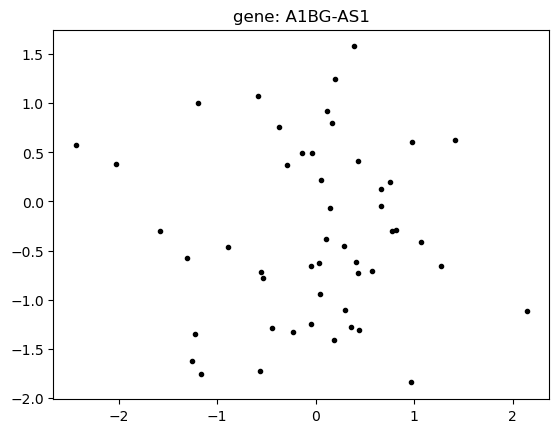

In [65]:
idx = 0
plt.figure() 
plt.plot(f(x_train[50:100].cpu().numpy()), x_train.detach().cpu()[50:100, np.abs(shap_values).mean(axis=0).nonzero()[0][idx]], 'k.')
plt.title(f'gene: {mds_expr_wide.columns[np.abs(shap_values).mean(axis=0).nonzero()[0][idx]]}')
plt.show()

# Survival regression

In [66]:
zdf = pd.DataFrame(z.cpu().numpy(), columns=[f'z{i}' for i in range(z.size(1))])
zdf = zdf.assign(id=ids)
zdf = zdf.assign(priorMDS_ids = np.isin(ids, priorMDS_ids))
zdf = zdf.assign(id_type = ['aml']*len(aml_ids) + ['mds']*len(mds_ids))

zdf = zdf.merge(aml_clin[['gdc_id', 'overallSurvival']], left_on='id', right_on='gdc_id', how='left')


In [67]:
zdf = pd.DataFrame(z.cpu().numpy(), columns=[f'z{i}' for i in range(z.size(1))])
zdf = zdf.assign(id=ids)
zdf = zdf.assign(priorMDS_ids = np.isin(ids, priorMDS_ids))
zdf = zdf.assign(id_type = ['aml']*len(aml_ids) + ['mds']*len(mds_ids))

zdf = zdf.merge(aml_clin[['gdc_id', 'overallSurvival']], left_on='id', right_on='gdc_id', how='left')

zdf = zdf[lambda x: x['overallSurvival'].notna()]

# log transform the overallSurvival
zdf = zdf.assign(overallSurvival=lambda x: np.log2(x['overallSurvival'] + 1))

z_test = zdf[lambda x: x.gdc_id.isin(priorMDS_ids)][zdf.columns[:model.latent_dim]].values 
y_test = zdf[lambda x: x.gdc_id.isin(priorMDS_ids)]['overallSurvival'].values 

z_train = zdf[~zdf.gdc_id.isin(priorMDS_ids)][zdf.columns[:model.latent_dim]].values
y_train = zdf[~zdf.gdc_id.isin(priorMDS_ids)]['overallSurvival'].values 

print(f'Train set size: {z_train.shape}')
print(f'Test set size: {z_test.shape}')

# split y_train into 3 classes based on quantiles 0.33, 0.66
yt = np.quantile(y_train, 0.5)

y_train = y_train < yt
y_test = y_test < yt

print('# positive samples in train:', np.sum(y_train))
print('# positive samples in test:', np.sum(y_test))
mod = RandomForestClassifier(n_estimators=500)

scores = cross_val_score(mod, z_train, y_train, cv=5, scoring='roc_auc')
print(f'Cross-validated ROC AUC: {np.mean(scores):.3f} +/- {np.std(scores):.3f}')

mod.fit(z_train, y_train)
y_pred = mod.predict_proba(z_test)[:, 1]

from sklearn.metrics import roc_auc_score, accuracy_score
roc_auc = roc_auc_score(y_test, y_pred)
acc = accuracy_score(y_test, y_pred > 0.5)
print(f'Test ROC AUC: {roc_auc:.3f}')   
print(f'Test accuracy: {acc:.3f}')

Train set size: (511, 32)
Test set size: (49, 32)
# positive samples in train: 255
# positive samples in test: 33
Cross-validated ROC AUC: 0.631 +/- 0.054
Test ROC AUC: 0.618
Test accuracy: 0.653


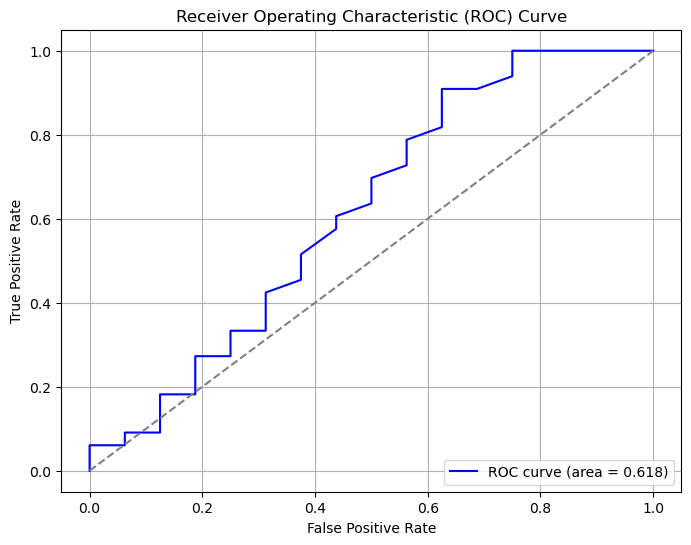

In [68]:
# auroc curve 
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label='ROC curve (area = {:.3f})'.format(roc_auc), color='blue')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid()
plt.show()

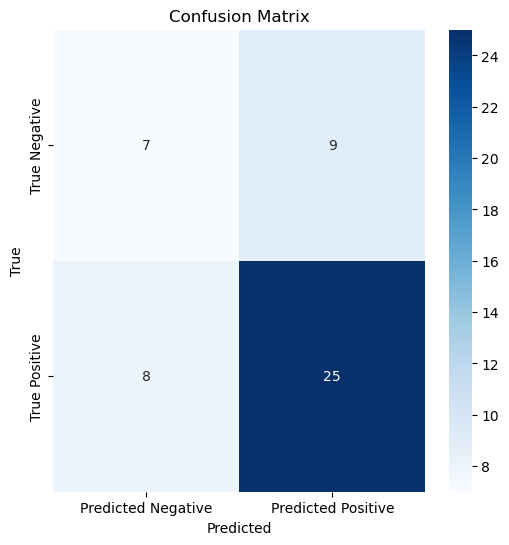

In [69]:
# confusion 
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred > 0.5)
import seaborn as sns
plt.figure(figsize=(6, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted Negative', 'Predicted Positive'], yticklabels=['True Negative', 'True Positive'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

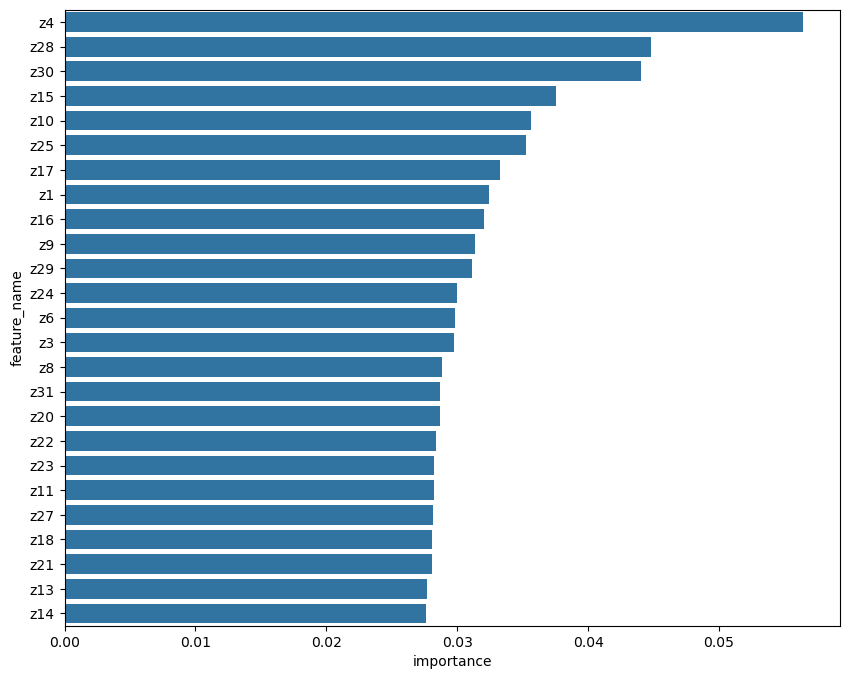

In [70]:
imp_df = pd.DataFrame({'importance':mod.feature_importances_, 'feature_name' : [f'z{i}' for i in range(model.latent_dim)]}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 8))
sbn.barplot(data=imp_df.head(25), y='feature_name', x='importance') 
plt.show() 

Spearman correlation between z11 and z27: -0.271, p-value: 6.896e-11


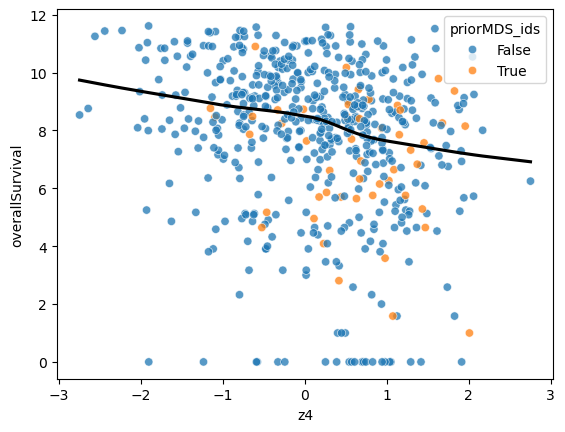

Spearman correlation between z11 and z27: -0.141, p-value: 8.302e-04


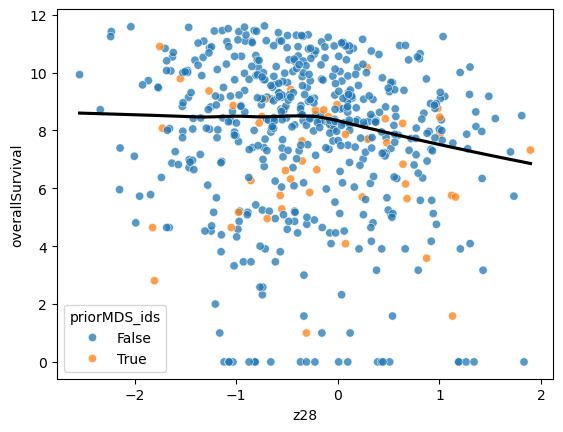

Spearman correlation between z11 and z27: -0.142, p-value: 7.746e-04


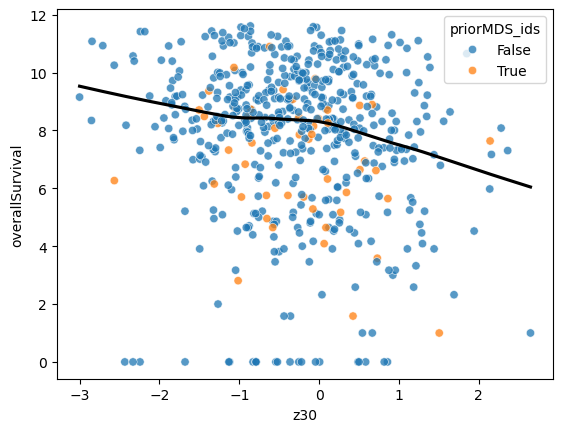

In [71]:
for f1 in imp_df.feature_name.values[:3]:

    corr = spearmanr(zdf[f1], zdf.overallSurvival)
    print(f'Spearman correlation between z11 and z27: {corr.statistic:.3f}, p-value: {corr.pvalue:.3e}')

    plt.figure() 
    sbn.scatterplot(data=zdf, x=f1, y='overallSurvival', hue='priorMDS_ids', alpha=0.75)
    sbn.regplot(data=zdf, x=f1, y='overallSurvival', ci=True, lowess=True, scatter=False, color='black')
    plt.show() 

In [72]:
aml_cl

NameError: name 'aml_cl' is not defined